In [7]:
import cv2 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [3]:
image_path = "../data/output/cropped_image.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

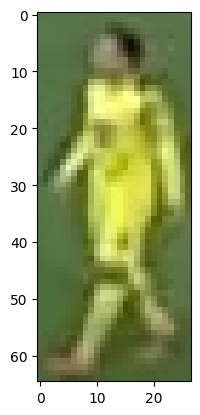

In [4]:
plt.imshow(image)
plt.show()

# Take the top half of image

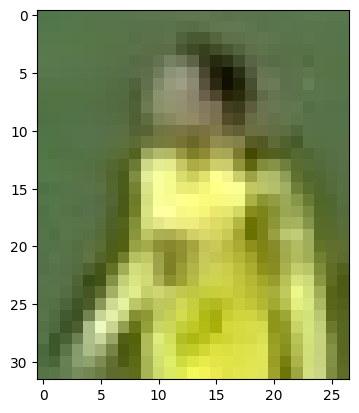

In [5]:
top_half = image[0 :int(image.shape[0]//2), :]
plt.imshow(top_half)
plt.show()

# Cluster image into two clusters

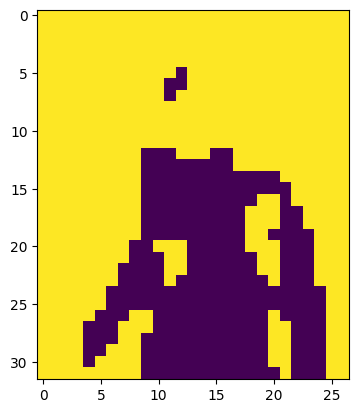

In [9]:
# Reshape the image to a 2D array of pixels
pixels = top_half.reshape(-1, 3)

# Use KMeans to find the dominant colors
kmeans = KMeans(n_clusters=2, random_state=0).fit(pixels)

# Get the cluster labels
labels = kmeans.labels_

# Reshape the labels into the original image shape
clastered_image = labels.reshape(top_half.shape[0], top_half.shape[1])

# Display the clustered image
plt.imshow(clastered_image)
plt.show()

In [10]:
corner_clasters = [clastered_image[0, 0], clastered_image[0, -1], clastered_image[-1, 0], clastered_image[-1, -1]]
non_player_claster = max(set(corner_clasters), key=corner_clasters.count)
print(f"Non player cluster: {non_player_claster}")

Non player cluster: 1


In [11]:
player_cluster = 1 - non_player_claster
print(f"Player cluster: {player_cluster}")

Player cluster: 0


In [12]:
kmeans.cluster_centers_[player_cluster]

array([199.04411765, 206.13970588,  93.99632353])